# Exploratory Data Analysis
Lab 1: week of September 14
*  claim a dataset
*  exploratory analysis
*  define target, frequency, and horizon

**Dataset Source:** The Bike Sharing Capital data set (both daily and hourly) was provided by the instructor <br>
**Target:** Next-day total bike rental (cnt) (still confused but I'll keep it like this for now) <br>
**Target Unit:** Number of bike rentals <br>
**Native Frequency:** Daily <br>
**Forecast Horizon:** 1 day? <br>
**Resampling:** no resampling needed, keeping it as daily <br>
**Coverage:** 2 years of coverage from January 1, 2011, to December 31, 2012  

In [6]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

#Data Loading
Our dataset is called Bike Sharing and contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information. It consists of 13 features and 17389 rows. The features are either integers or real numbers.

The source of this data provides two different datasets each sampled at a different frequency (by the day and by the hour). The first 5 rows of each dataset are displayed in the two cells below.

In [45]:
print("Start:", df.index.min())
print("End:", df.index.max())

Start: 2011-01-01 00:00:00
End: 2012-12-31 00:00:00


In [7]:
#load dataset with sampling frequency of each day
df = pd.read_csv('day.csv')
#display the first 5 rows
df.head()




,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [8]:
#show the dataframe shape
df.shape

(731, 16)

In [9]:
# load and display data for sampling frequency of every hour
df2 = pd.read_csv('hour.csv')
df2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [10]:
# display the shape
df2.shape

(17379, 17)

We have a decision to make: do we use the hourly dataset or the day dataset?
After plotting both, hourly data is very dense. It is hard to see patterns. It would need to be resampled anyway. Maybe our resampling rule should be "go with day to day" rather than hourly.

Note that the shape of the hourly dataset is huge. There are 17379 rows in hour.csv compared to 731 in the day.csv dataset. Downsampling can reduce computational complexity for analysis, whereas upsampling can provide insight at a different resolution.

In [11]:
# show column names, types and non-null value counts for day dataset
df.info()
# repeat with hourly dataset
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

Actually need to verify is any value is missing.
We have a regular index.

In [12]:
print("Missing Values for Daily Data Set:")
print(df.isna().sum())

Missing Values for Daily Data Set:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [13]:
print("Missing Values for Hourly Data Set:")
print(df2.isna().sum())

Missing Values for Hourly Data Set:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Great news: there are no missing values.
However, there is a large difference in # of rows depending on if we choose to include hr data or not.


Below is code to get a column called date of datetime type. Datetime objects are python objects that contain all the information of both a date object and a time object. Year, month, day are necessary and hr is the most amount of time data we have.

In [14]:
df = df.rename(columns={'dteday': 'date'})
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date') #make date the new index for this to be a true time series
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
date,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [15]:
# display some descriptive statistics on the daily dataset
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [16]:
#.astype() casts argument to a specified dtype
# therefore, hr goes from numeric to string type before being added to datetime object
df2['date'] = pd.to_datetime(df2['dteday'] + ' ' + df2['hr'].astype(str) + ':00:00')
# make another version of df where date is the index
df2 = df2.set_index('date')
df2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
date,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
2011-01-01 01:00:00,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2011-01-01 02:00:00,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
2011-01-01 03:00:00,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
2011-01-01 04:00:00,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [17]:
# explore statistics of hourly dataset
df2.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Descriptive statistics show no missing values.

6 of these columns are categorical, including:

Season (1=winter, 2=spring, 3=summer, 4=fall)

Year (year 0 = 2011, 1 = 2012)

Month (1 to 12)

Hour (0 to 23)

Weekday (1 to 7)

Weathersit - 1: Clear, Few clouds, Partly cloudy, Partly cloudy

# Resampling Analysis

Below we visualize the same dataset but one with a sampling frequency of each day and the other each hour. For simplicity, we look at just the bike count values over time. We have multiple plots to show different resolutions.

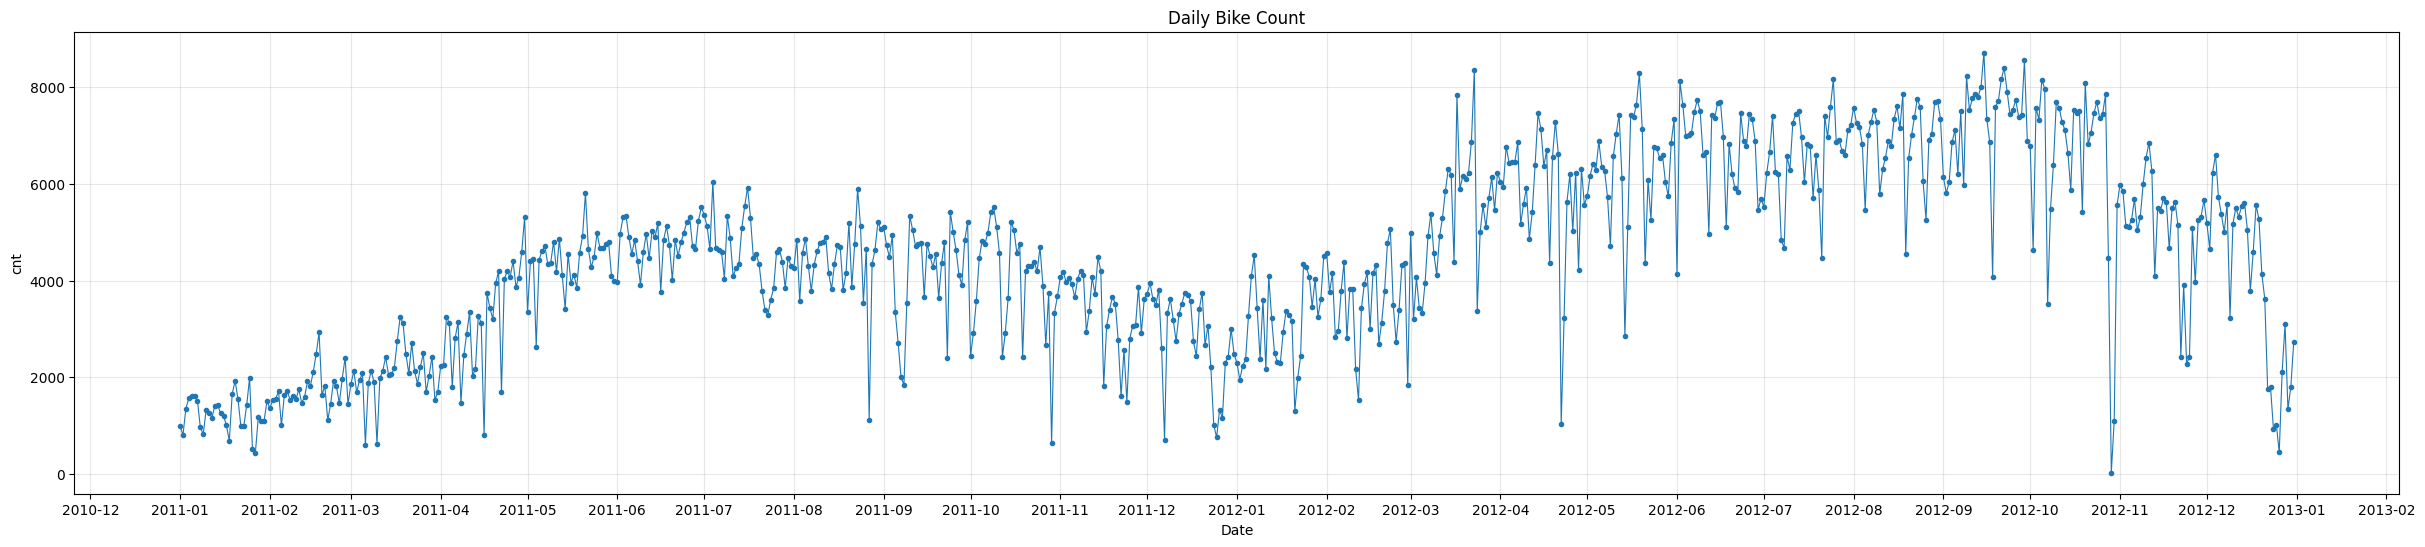

In [38]:
#create univariate dataset of daily bike count values
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(30, 6))
ax.plot(df.index, df['cnt'], marker='.', linewidth=0.8)
plt.title('Daily Bike Count')
# Tick every week on Monday
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=1)
)
ax.set_ylabel('cnt')
ax.grid(alpha=0.3)
ax.set_xlabel('Date')
plt.show()

The "Daily Bike Count" plot shows the entire dataset 'cnt' values. Seasonality can be observed from year to year. Higher bike counts occur in summer and fall months while low bike counts occur in winter.

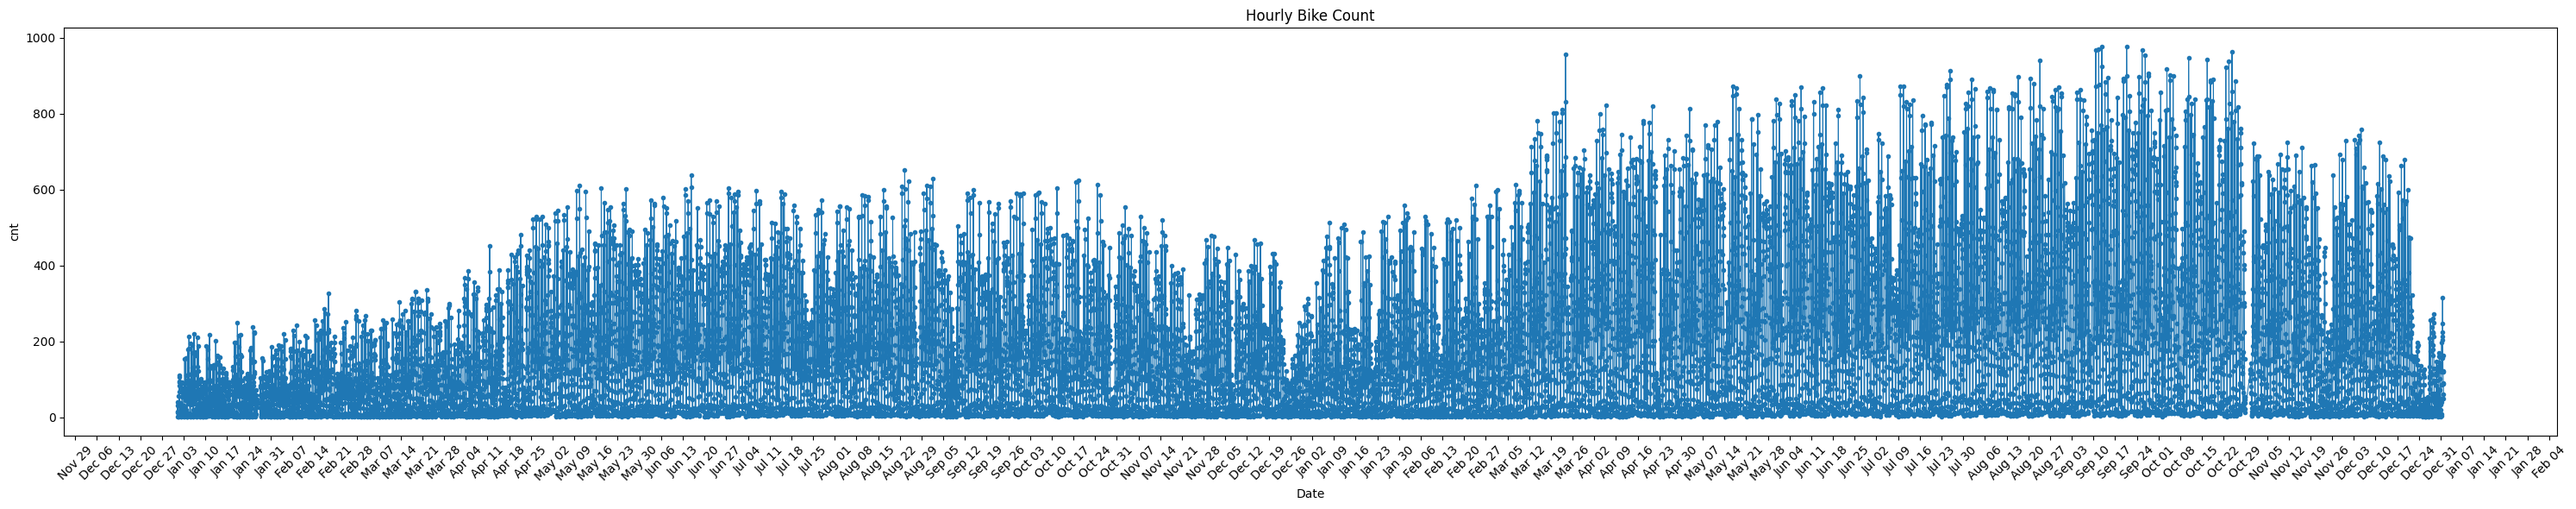

In [27]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(30, 6))
ax.plot(df2.index, df2['cnt'], marker='.', linewidth=0.8)
# Tick every week on Monday
ax.xaxis.set_major_locator(
    mdates.WeekdayLocator(byweekday=mdates.MONDAY)
)
# Format the tick labels
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.title('Hourly Bike Count')
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('cnt')
plt.tight_layout()
plt.show()

The "Hourly Bike Count" plot shows the entire dataset's 'cnt' values at an hourly basis. The weekly labels on the x-axis show some seasonality observed at the weekly level.

**Plot for Daily Bike Count for January**

Visualize data at different resolution (zoomed in on 1 month)

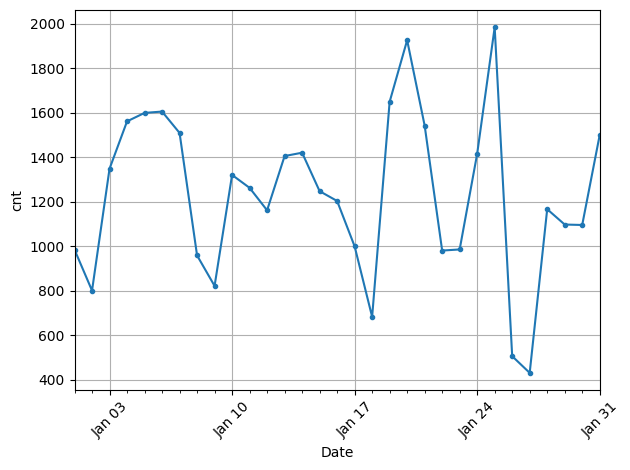

In [29]:
df_2011_01 = df.loc['2011-01']
cnt_Ddata_2011 = df_2011_01['cnt']
ax = cnt_Ddata_2011.plot(ylabel='cnt', marker = '.', grid=True)
# Tick every week on Monday
ax.xaxis.set_major_locator(
    mdates.WeekdayLocator(byweekday=mdates.MONDAY)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %d')
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.xlabel('Date')
plt.ylabel('cnt')
plt.show()

Daily Bike Count in the month of January 2011 plotted with date labels on the monday of each week shows there is no seasonality by week.

**Plot for Hourly Bike Count on January 1st, 2011**

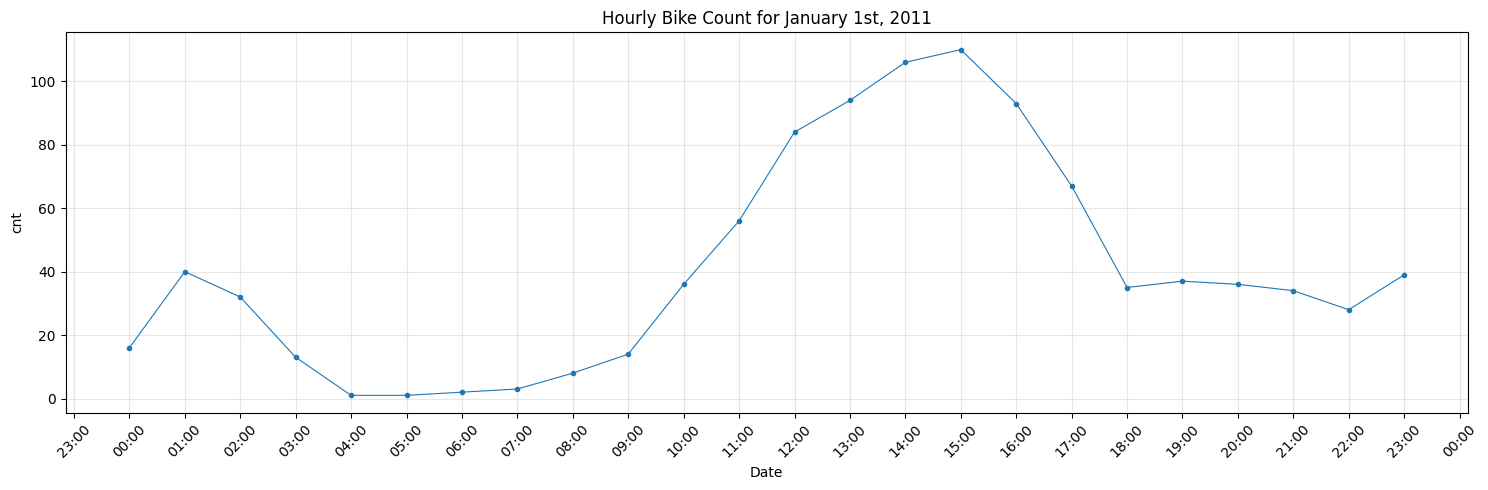

In [30]:
df2_2011_01_01 = df2.loc['2011-01-01']
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df2_2011_01_01.index, df2_2011_01_01['cnt'], marker='.', linewidth=0.8)
# Tick every hour of this day
ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=1)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%H:%M')
)
plt.title('Hourly Bike Count for January 1st, 2011')
plt.xlabel('Date')
plt.ylabel('cnt')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The plot "Hourly Bike Count for January 1st, 2011" indicates there may be seasonality in the hourly bike count data. Higher bike counts occur during the day than the night.

Where there is no sampling requirement, the sampling frequency can be choosen for the task at hand. Enough useful information can be drawn from daily bike counts in forecasting.

# Visualize the raw data

Displayed below are 7 plots displaying values of each numeric variable in this daily dataset against the index for time (date).

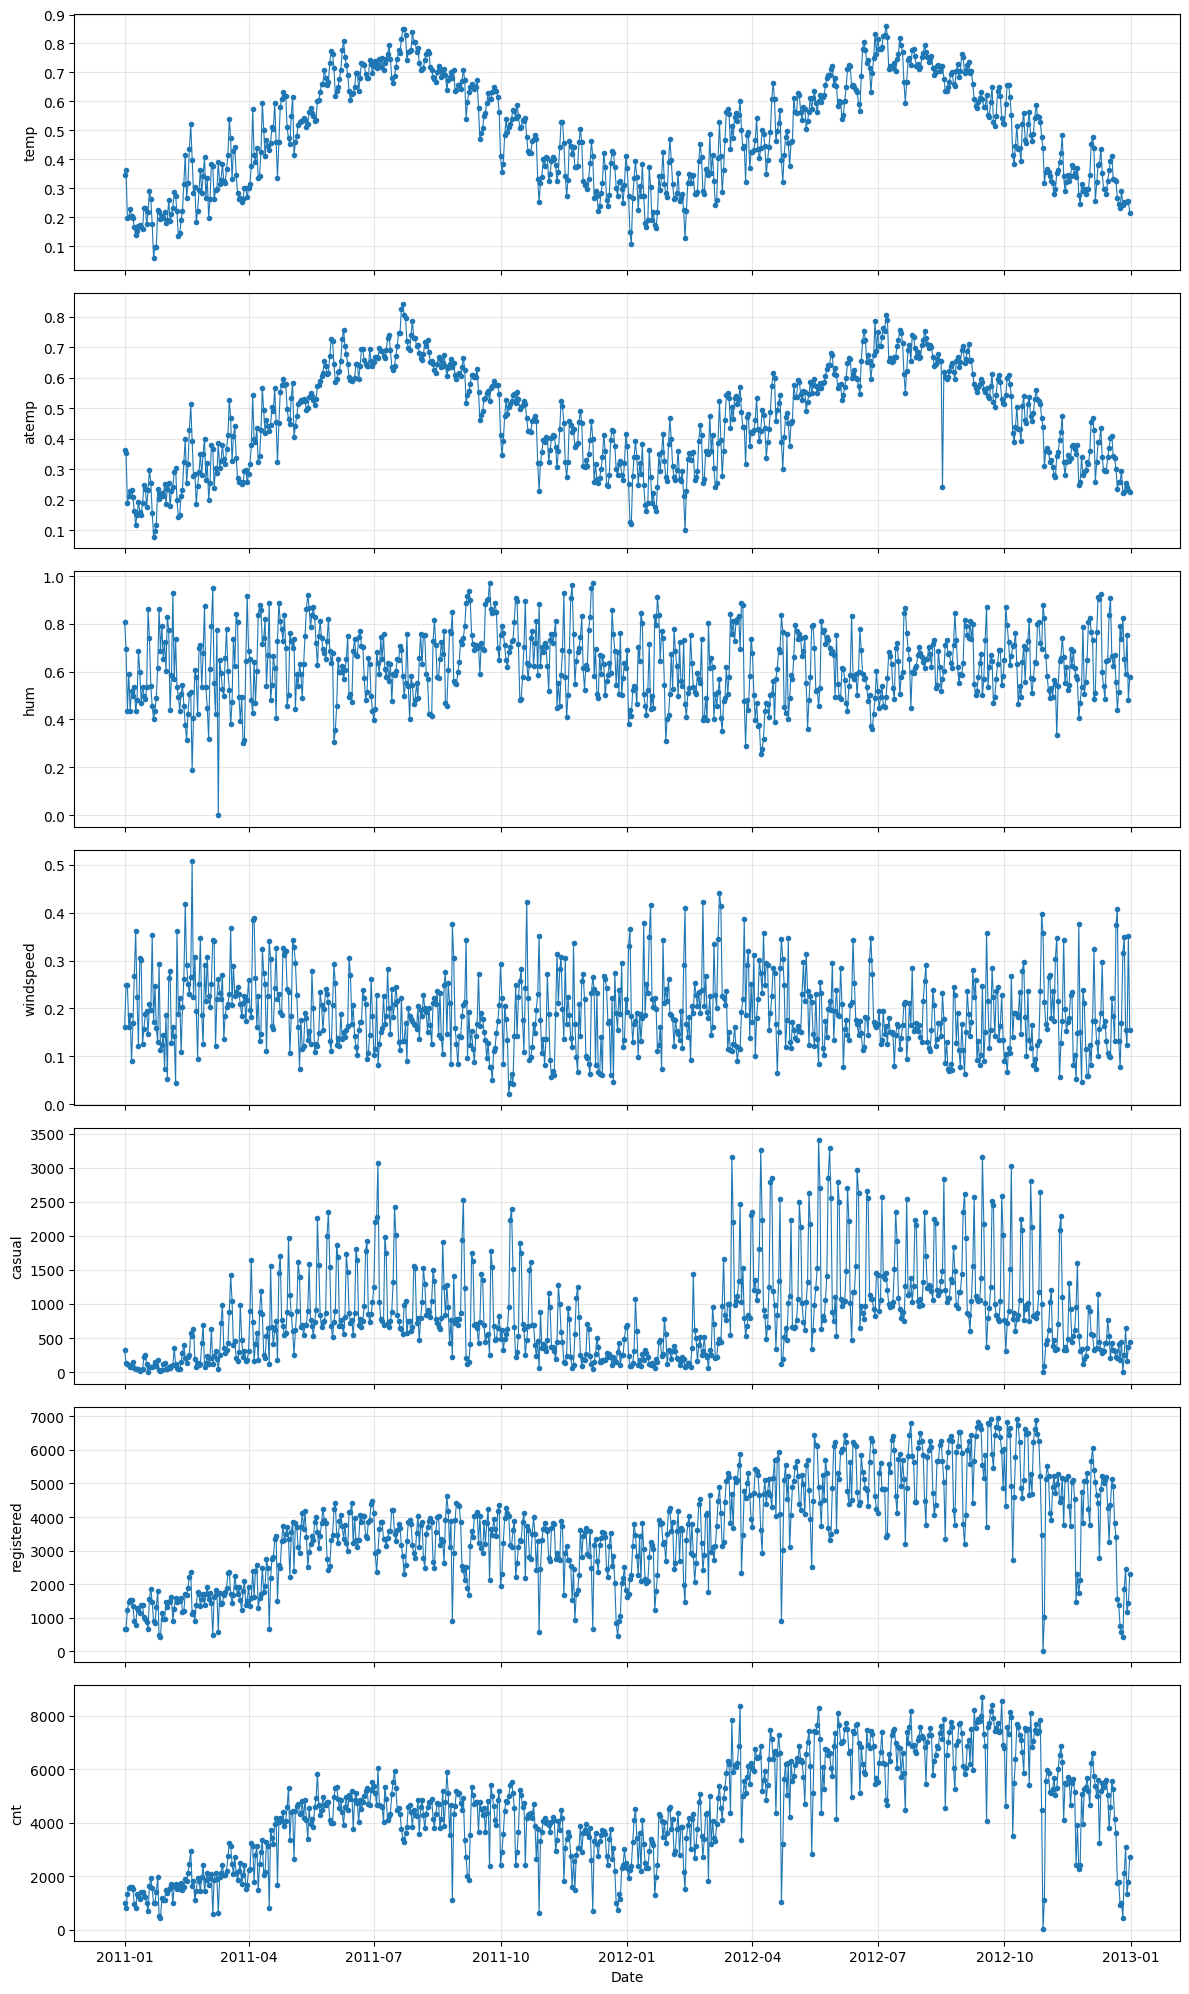

In [21]:
# define the numeric variables to plot over time
cont_variables = [
    'temp', 'atemp', 'hum', 'windspeed',
    'casual', 'registered', 'cnt'
]

fig, axes = plt.subplots(
    nrows=7,
    ncols=1,
    figsize=(12, 20),
    sharex=True
)

for ax, var in zip(axes, cont_variables):
    ax.plot(df.index, df[var], marker='.', linewidth=0.8)
    ax.set_ylabel(var)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.show()

# Closer Look at Seasonality

# Check for Stationarity

We will determine if our daily dataset is stationary or not by using Augmented Dickey-Fuller (ADF) statistical test, rejecting the null hypothesis if p-value is greater than 0.05. Additionally, we will verify the results by visual inspection of the graphs above.

In [39]:
from statsmodels.tsa.stattools import adfuller

for var in cont_variables:
    X = df[var]
    result = adfuller(X)
    print('ADF Statistic (%s): %f' % (var, result[0]))
    print('p-value: %f' % result[1])

    if result[1] <= 0.05:
        print('Reject the null hypothesis. Data has no unit root and is stationary.\n')
    else:
        print('Fail to reject the null hypothesis. Data has a unit root and is non-stationary.\n')

ADF Statistic (temp): -1.966226
p-value: 0.301575
Reject the null hypothesis. Data has a unit root and is non-stationary.

ADF Statistic (atemp): -2.074119
p-value: 0.255048
Reject the null hypothesis. Data has a unit root and is non-stationary.

ADF Statistic (hum): -5.146517
p-value: 0.000011
Fail to reject the null hypothesis. Data has a unit root and is stationary.

ADF Statistic (windspeed): -4.260564
p-value: 0.000519
Fail to reject the null hypothesis. Data has a unit root and is stationary.

ADF Statistic (casual): -1.817285
p-value: 0.371914
Reject the null hypothesis. Data has a unit root and is non-stationary.

ADF Statistic (registered): -1.851067
p-value: 0.355419
Reject the null hypothesis. Data has a unit root and is non-stationary.

ADF Statistic (cnt): -1.877448
p-value: 0.342743
Reject the null hypothesis. Data has a unit root and is non-stationary.



According to the ADF statistical test, windspeed and humidity are the two variables that are stationary. This means, their mean and variance are consistent over time. This is corroborated by visual inspection from the graphs above. Windspeed and humidity graphs both look very flat over time and the variance is consistently the same height.

The remaining numeric variables should be made stationary to make statistical modelling easier.


# Data Transformations
The orange line is the 24-day moving average, while the blue line shows the actual daily bike counts. The moving average is smoother with less noise, making it easier to see overall trends and seasonal changes in bike rentals.

<Axes: xlabel='date'>

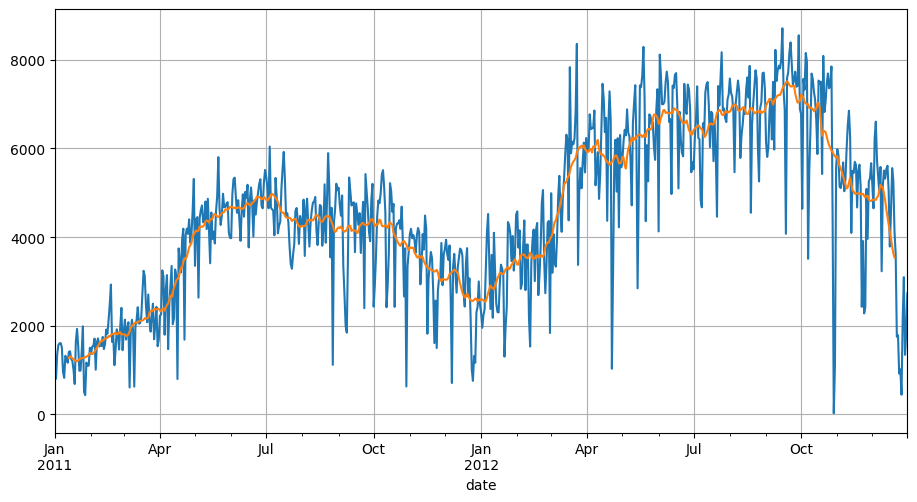

In [23]:
#use a simple rolling 24 average transformation to see trend and seasonality
from numpy.strings import center
cnt_data_daily = df['cnt']
trend_24 = cnt_data_daily.rolling(24, center=True).mean()

fig, ax = plt.subplots(figsize=(11,5.5))
cnt_data_daily.plot(ax=ax, label='Daily')
trend_24.plot(ax=ax, label='24-day moving avg',grid=True)

# Attempt to make the data stationary

Applying a log transform to just the cnt data

<Axes: xlabel='date'>

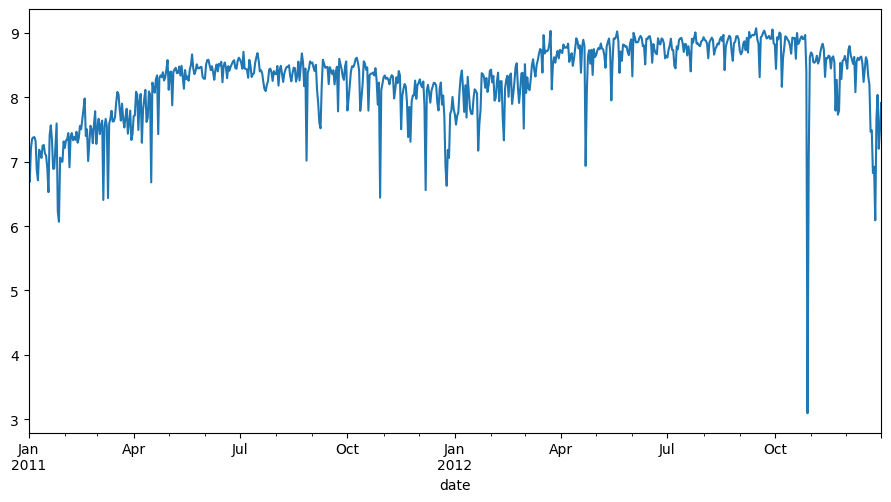

In [24]:
import numpy as np
#apply a log transform to the cnt data to see if the data can be made more stationary
log_df = np.log(df['cnt'])
fig, ax = plt.subplots(figsize=(11,5.5))
log_df.plot(ax=ax,label='cnt')

# Lag Analysis

Used to determine window

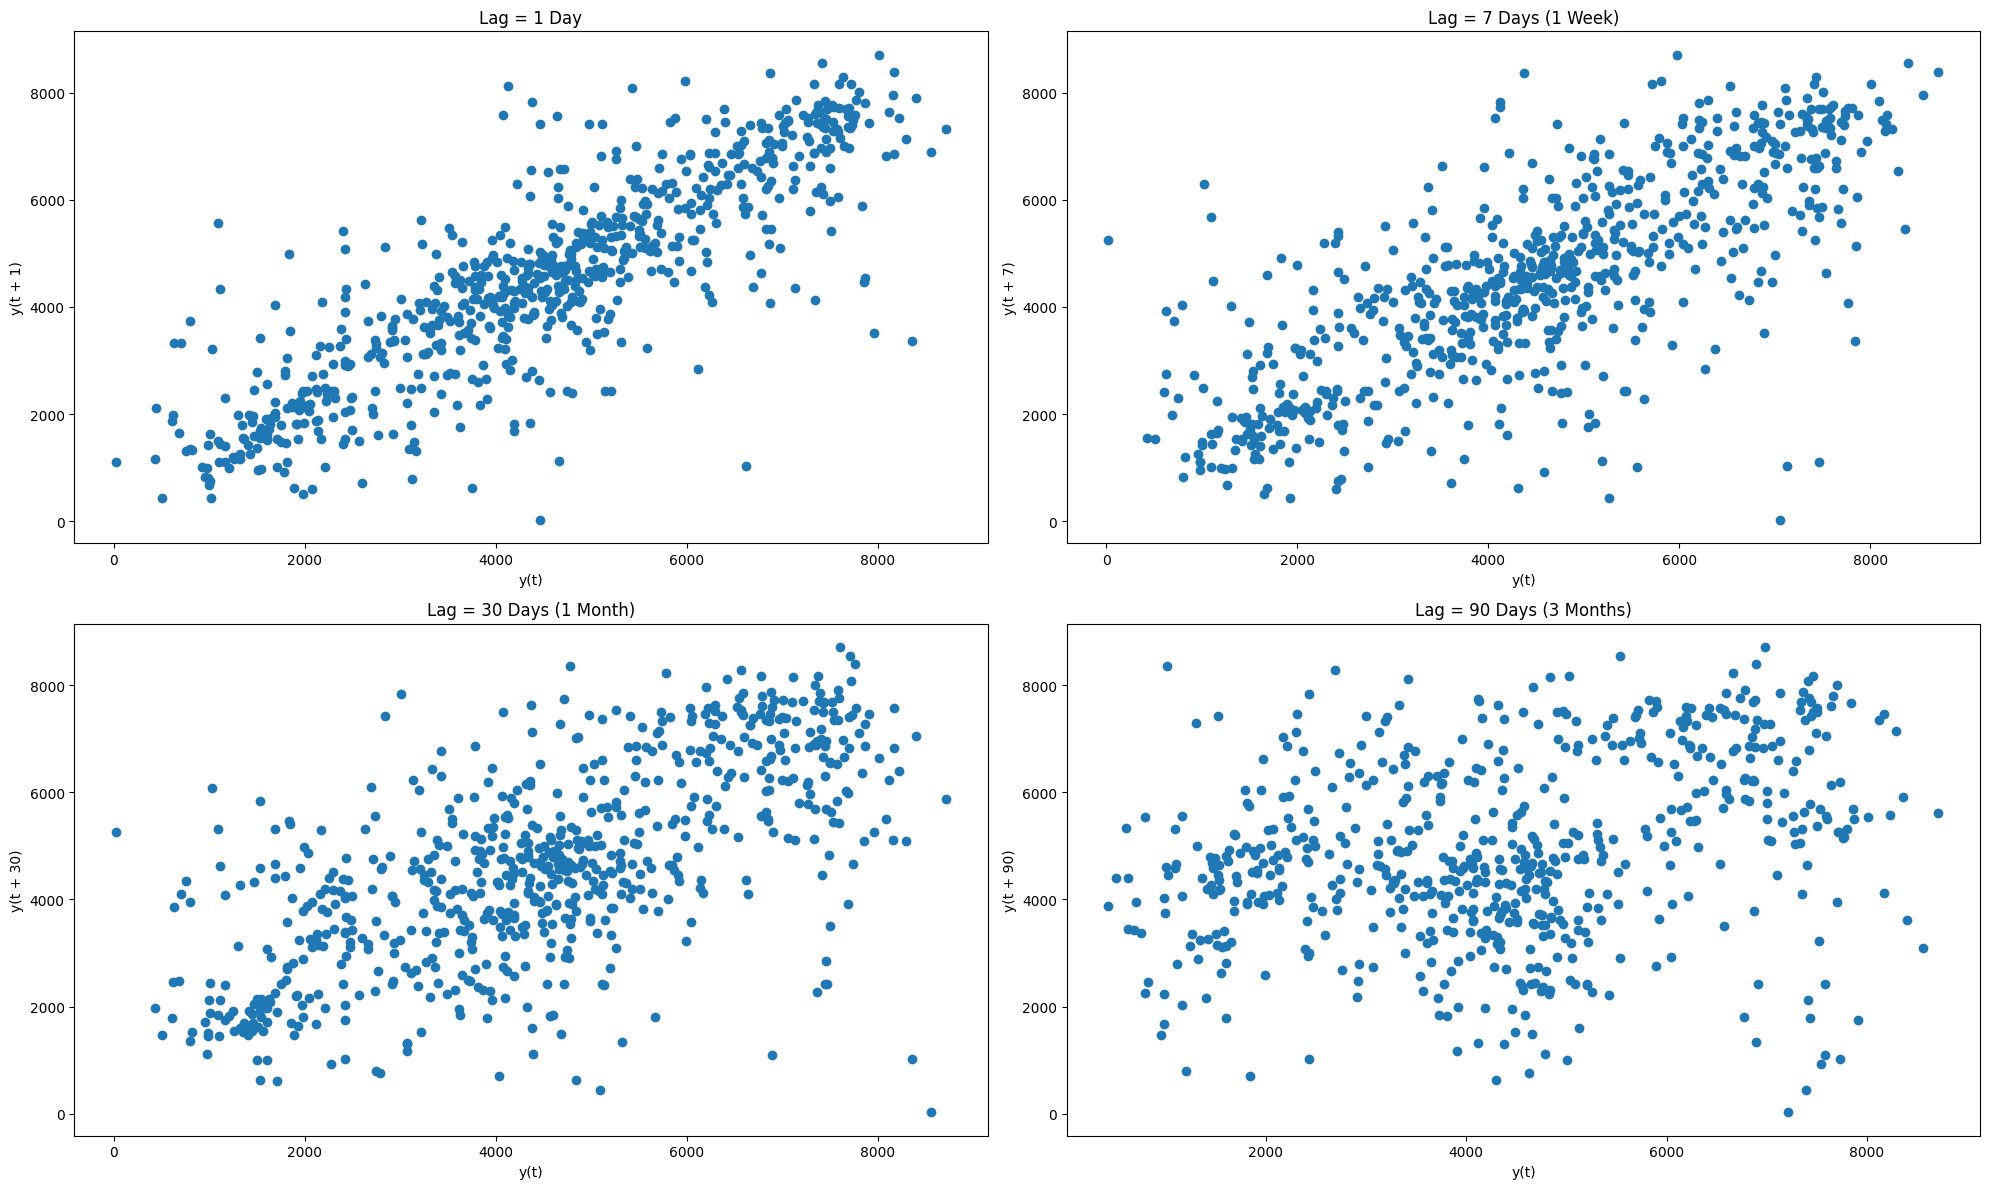

In [25]:
# Create space for the 4 graphs
plt.figure(figsize=(20, 12))

# 1 Day
plt.subplot(2, 2, 1)
pd.plotting.lag_plot(df['cnt'], lag=1)
plt.title('Lag = 1 Day')

# 1 Week
plt.subplot(2, 2, 2)
pd.plotting.lag_plot(df['cnt'], lag=7)
plt.title('Lag = 7 Days (1 Week)')

# 1 month
plt.subplot(2, 2, 3)
pd.plotting.lag_plot(df['cnt'], lag=30)
plt.title('Lag = 30 Days (1 Month)')

# 3 Months
plt.subplot(2, 2, 4)
pd.plotting.lag_plot(df['cnt'], lag=90)
plt.title('Lag = 90 Days (3 Months)')

# Prevent graphs from overlapping
plt.tight_layout()

# Display graphs
plt.show()

Based off the graphs, 1-day and 7-day lags show strong positive dependence. Much more scattered and dispersed and 30 days and basically nonexistent at 3 months. L of maybe 1 or 7??

<Axes: >

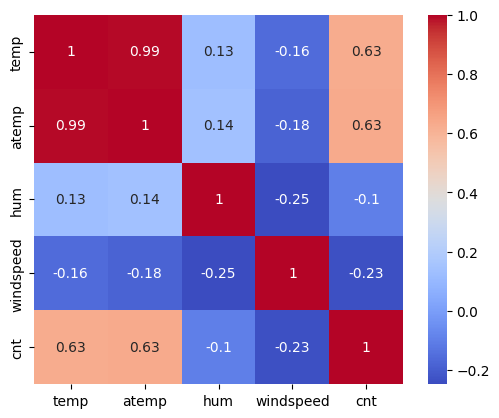

In [26]:
# Correlation Analysis
df_corr_vals = df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
df_corr_vals

# Correlation Heatmap
sns.heatmap(df_corr_vals, square=True, annot=True, cmap='coolwarm')

**Strongest Positive Relationships**

temp --> cnt: 0.63 --> warmer temperature = generally more bike rentals<br>
atemp --> cnt: 0.63 --> warmer temperature = generally more bike rentals <br>
temp --> atemp: 0.99 (atemp and temp are basically the same thing)

**Strongest Negative Relationships**

windspeed --> cnt: -0.23 = higher windspeed is linked to fewer bike rentals<br>
humidity --> windspeed: -0.25 = humidity increases, windpseeds tends to decrease


Need to decide on a look back horizon before modelling.

**What is our target?** how far into the future

**What will our input be?** how far into the past will we use?

Once we decide L and h we can determine our windows.

**What is our forecasting goal?** what questions do we want to be able to answer with our forecasting tool? Predict number of users next year? or predict number of users on a rainy day?

Summary of Dataset
*   it is multivariate
*   sampling is regular, each day. no missed values bc of the sensors.
*   there is seasonality
*   List item

Questions:
*  can we use categorical data?
*   List item







# Compute the Baseline

The baseline is a trivial forecast used to compare to other models to see if they learned anything at all.

What metrics will we use to compare performance?